# 低波动因子研究

**研究目标**：验证低波动异象在A股市场的有效性

**因子**：
- 已实现波动率因子（20日滚动，年化）
- Beta因子（60日滚动，相对沪深300）
- 合成低波动因子（0.5:0.5加权）

**研究框架**：IC分析 → 分层回测 → 因子衰减 → A股低波动异象解读

## Section 0: 参数设置

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import os

# 添加项目根目录到路径
sys.path.insert(0, os.path.abspath('../../..'))

# 中文字体
matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'SimHei', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False

# ─── 研究参数 ───────────────────────────────────────────
START_DATE = '2018-01-01'
END_DATE   = '2023-12-31'
VOL_WINDOW  = 20        # 波动率滚动窗口（日）
BETA_WINDOW = 60        # Beta 滚动窗口（日）
N_GROUPS    = 10        # 分层回测分组数
IC_METHOD   = 'spearman'  # IC 计算方法
DECAY_HORIZONS = [1, 5, 10, 20, 60]  # 因子衰减检验周期
N_STOCKS    = 100       # 模拟股票数量
TRANSACTION_COST = 0.003  # 双边交易成本 0.3%

print('✅ 参数设置完成')
print(f'   回测区间: {START_DATE} ~ {END_DATE}')
print(f'   波动率窗口: {VOL_WINDOW}日 | Beta窗口: {BETA_WINDOW}日')
print(f'   分层数: {N_GROUPS} | IC方法: {IC_METHOD}')

✅ 参数设置完成
   回测区间: 2018-01-01 ~ 2023-12-31
   波动率窗口: 20日 | Beta窗口: 60日
   分层数: 10 | IC方法: spearman


## Section 1: 数据构建

> **注意**：此处使用 mock 数据，实际研究需替换为真实行情数据

In [2]:
# 需要真实数据
# 真实数据加载示例（需要配置好数据源）:
# from utils.data_loader import get_stock_history, get_index_history
# 股票池：沪深300成分股（使用当时的成分股，避免幸存者偏差）
# 市场：沪深300指数（代码 000300.SH）

# ─── 构造 mock 价格数据（用于流程验证）─────────────────────
np.random.seed(42)
dates = pd.bdate_range(START_DATE, END_DATE)
symbols = [f'SH{i:06d}' for i in range(N_STOCKS)]

# 模拟价格：GBM（几何布朗运动）
# 不同股票有不同波动率（高波动/低波动混合）
vols = np.linspace(0.15, 0.60, N_STOCKS)  # 年化波动率从15%到60%
daily_vols = vols / np.sqrt(252)
daily_drift = 0.08 / 252  # 年化8%的期望收益

price_data = np.ones((len(dates), N_STOCKS))
for t in range(1, len(dates)):
    shock = np.random.randn(N_STOCKS) * daily_vols
    # 低波动股票有轻微"低波动溢价"（模拟真实异象）
    alpha = (1 - vols / vols.max()) * 0.02 / 252  # 低波动股票额外收益
    price_data[t] = price_data[t-1] * np.exp(daily_drift + alpha + shock)

price_wide = pd.DataFrame(price_data, index=dates, columns=symbols)

# 计算日收益率
ret_wide = price_wide.pct_change().dropna()

# 模拟市场（沪深300）收益率
# 需要真实数据 — 替换为 get_index_history('000300.SH')
market_ret = pd.Series(
    np.random.randn(len(ret_wide)) * 0.013 + 0.0003,
    index=ret_wide.index,
    name='HS300'
)

print(f'✅ 数据构建完成')
print(f'   收益率宽表: {ret_wide.shape} | 时间: {ret_wide.index[0].date()} ~ {ret_wide.index[-1].date()}')
print(f'   市场指数: {market_ret.shape[0]} 个交易日')

# 数据质量检查
assert ret_wide.shape[0] > 100, f'数据行数异常: {ret_wide.shape[0]}'
assert ret_wide.isnull().mean().max() < 0.1, f'缺失值过多: {ret_wide.isnull().mean().max():.1%}'
assert ret_wide.index.is_monotonic_increasing, '日期未排序'
print(f'✅ 数据质量检查通过')

✅ 数据构建完成
   收益率宽表: (1564, 100) | 时间: 2018-01-02 ~ 2023-12-29
   市场指数: 1564 个交易日
✅ 数据质量检查通过


## Section 2: 因子计算

In [3]:
from research.factors.low_vol.low_vol_factor import (
    compute_realized_vol,
    compute_beta,
    compute_composite_low_vol,
)

# 计算波动率因子
print('计算已实现波动率因子...')
vol_factor = compute_realized_vol(ret_wide, window=VOL_WINDOW)
print(f'  ✅ vol_factor: {vol_factor.shape} | 非空值: {vol_factor.notna().sum().sum()}')

# 计算 Beta 因子
print('计算 Beta 因子（可能耗时较长）...')
beta_factor = compute_beta(ret_wide, market_ret, window=BETA_WINDOW)
print(f'  ✅ beta_factor: {beta_factor.shape} | 非空值: {beta_factor.notna().sum().sum()}')

# 合成低波动因子
print('合成低波动因子...')
composite_factor = compute_composite_low_vol(vol_factor, beta_factor, weights=(0.5, 0.5))
print(f'  ✅ composite_factor: {composite_factor.shape} | 非空值: {composite_factor.notna().sum().sum()}')

# 对齐下期收益率（shift(1)：使用今日因子，买明日开盘，避免未来函数）
ret_shifted = ret_wide.shift(-1)  # 下一日收益率（用于IC计算）

print()
print('因子值截面统计（最新一日）:')
latest = composite_factor.iloc[-1].dropna()
print(f'  均值: {latest.mean():.4f} | 标准差: {latest.std():.4f}')
print(f'  最小值: {latest.min():.4f} | 最大值: {latest.max():.4f}')

计算已实现波动率因子...
  ✅ vol_factor: (1564, 100) | 非空值: 154900
计算 Beta 因子（可能耗时较长）...


  ✅ beta_factor: (1564, 100) | 非空值: 151600
合成低波动因子...
  ✅ composite_factor: (1564, 100) | 非空值: 151600

因子值截面统计（最新一日）:
  均值: -0.0000 | 标准差: 0.7088
  最小值: -2.5559 | 最大值: 1.0383


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


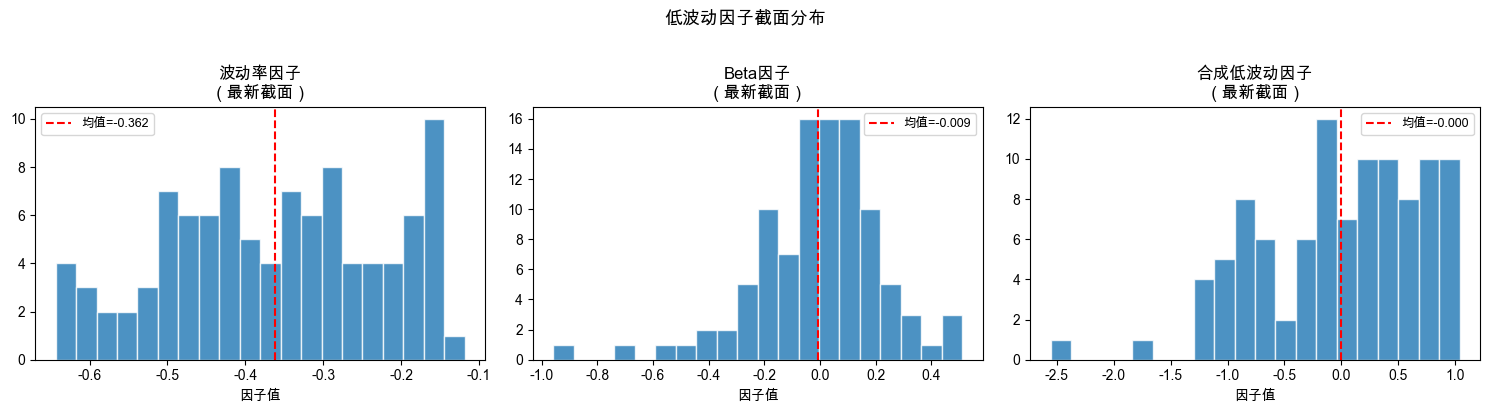

In [4]:
# 因子分布可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (fac, name) in zip(axes, [
    (vol_factor, '波动率因子'),
    (beta_factor, 'Beta因子'),
    (composite_factor, '合成低波动因子'),
]):
    vals = fac.iloc[-1].dropna()
    ax.hist(vals, bins=20, edgecolor='white', alpha=0.8)
    ax.axvline(vals.mean(), color='red', linestyle='--', label=f'均值={vals.mean():.3f}')
    ax.set_title(f'{name}\n（最新截面）')
    ax.legend(fontsize=9)
    ax.set_xlabel('因子值')

plt.suptitle('低波动因子截面分布', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 3: IC / ICIR 分析

In [5]:
from utils.factor_analysis import compute_ic_series, ic_summary

# 三个因子的 IC 分析
factors = {
    '波动率因子': vol_factor,
    'Beta因子': beta_factor,
    '合成低波动因子': composite_factor,
}

ic_results = {}
for name, fac in factors.items():
    ic_s = compute_ic_series(fac, ret_shifted, method=IC_METHOD)
    ic_results[name] = ic_s
    ic_summary(ic_s, name=name)

/opt/homebrew/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


【波动率因子】IC 统计摘要
  IC 均值    : 0.0012
  IC 标准差  : 0.1022
  ICIR       : 0.0116
  IC>0 占比  : 49.94%
  t 统计量   : 0.4582  (|t|>2 视为显著)



【Beta因子】IC 统计摘要
  IC 均值    : -0.0043
  IC 标准差  : 0.1083
  ICIR       : -0.0393
  IC>0 占比  : 47.39%
  t 统计量   : -1.5313  (|t|>2 视为显著)



【合成低波动因子】IC 统计摘要
  IC 均值    : -0.0028
  IC 标准差  : 0.1052
  ICIR       : -0.0269
  IC>0 占比  : 48.05%
  t 统计量   : -1.0456  (|t|>2 视为显著)



findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


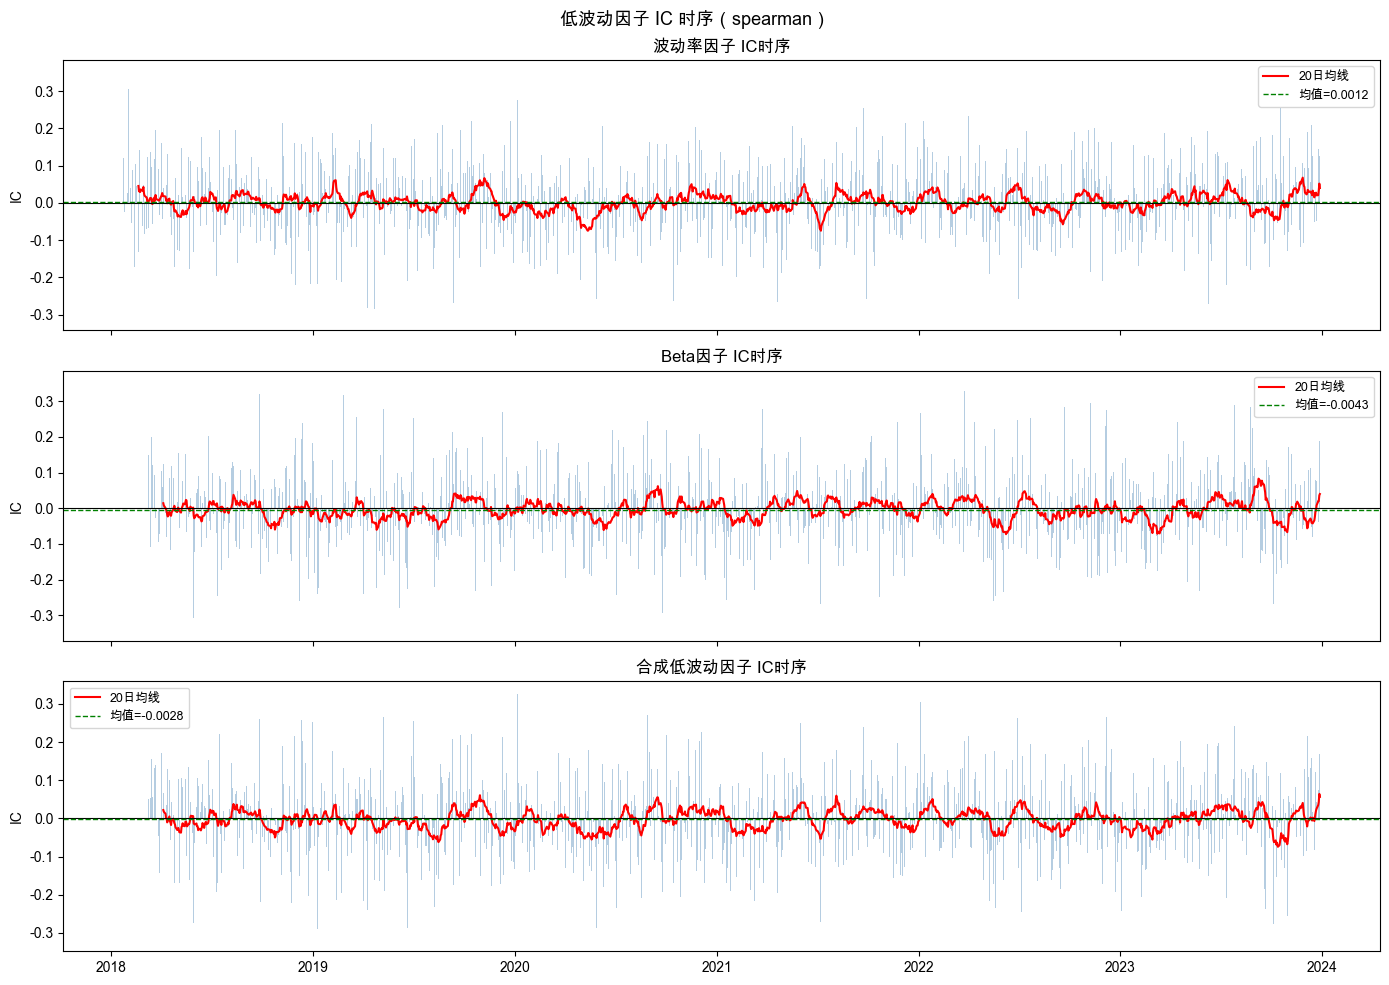

In [6]:
# IC 时序图
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (name, ic_s) in zip(axes, ic_results.items()):
    ic_clean = ic_s.dropna()
    ax.bar(ic_clean.index, ic_clean.values, alpha=0.4, color='steelblue', width=1)
    ax.plot(ic_clean.rolling(20).mean().index,
            ic_clean.rolling(20).mean().values,
            color='red', lw=1.5, label='20日均线')
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(ic_clean.mean(), color='green', linestyle='--', lw=1,
               label=f'均值={ic_clean.mean():.4f}')
    ax.set_title(f'{name} IC时序')
    ax.legend(fontsize=9)
    ax.set_ylabel('IC')

plt.suptitle(f'低波动因子 IC 时序（{IC_METHOD}）', fontsize=13)
plt.tight_layout()
plt.show()

=== 合成低波动因子衰减分析 ===


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


             1       5       10      20      60
mean_ic -0.0028 -0.0140 -0.0206 -0.0268 -0.0415
std_ic   0.1052  0.1118  0.1110  0.1095  0.1132
icir    -0.0269 -0.1248 -0.1852 -0.2445 -0.3668



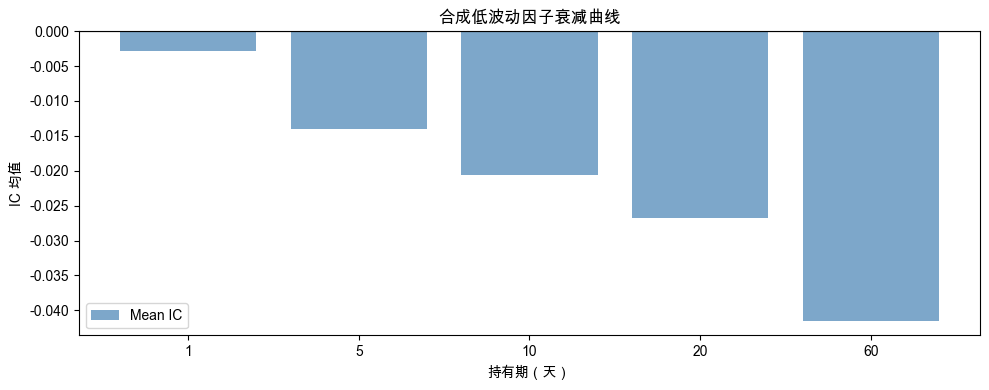

In [7]:
# 因子衰减分析（手动实现，因 factor_decay_analysis 尚未合入 utils）
print('=== 合成低波动因子衰减分析 ===')

decay_rows = {}
for h in DECAY_HORIZONS:
    fwd_ret_h = ret_wide.shift(-h).rolling(h).mean()  # h 日平均收益
    ic_h = compute_ic_series(composite_factor, fwd_ret_h, method=IC_METHOD)
    ic_clean = ic_h.dropna()
    decay_rows[h] = {
        'mean_ic': ic_clean.mean(),
        'std_ic':  ic_clean.std(),
        'icir':    ic_clean.mean() / ic_clean.std() if ic_clean.std() > 0 else float('nan'),
    }

decay_df = pd.DataFrame(decay_rows)
print(decay_df.round(4))
print()

# 衰减曲线图
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([str(h) for h in DECAY_HORIZONS], decay_df.loc['mean_ic'].values, color='steelblue', alpha=0.7, label='Mean IC')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('持有期（天）')
ax.set_ylabel('IC 均值')
ax.set_title('合成低波动因子衰减曲线')
ax.legend()
plt.tight_layout()
plt.show()

## Section 4: 分层回测（10分位）

In [8]:
from utils.factor_analysis import quintile_backtest

# 分层回测：Q1=低波动（因子值最小，即高波动），Q10=高波动（因子值最大，即低波动）
# 注意：因子取负后，Q10对应原始低波动股票
group_ret, ls_ret = quintile_backtest(
    composite_factor,
    ret_shifted,
    n_groups=N_GROUPS,
    long_short='Qn_minus_Q1'  # Qn（低波动）做多，Q1（高波动）做空
)

# 扣除交易成本（假设每月换仓一次，双边0.3%）
rebalance_freq = 20  # 每20日换仓一次
daily_cost = TRANSACTION_COST / rebalance_freq
ls_ret_after_cost = ls_ret - daily_cost

print('各分组年化收益（扣费前）:')
for col in group_ret.columns:
    ann = group_ret[col].dropna().mean() * 252
    print(f'  {col}: {ann:.2%}')

print(f'\n多空组合年化收益（Q10-Q1，扣费后）: {ls_ret_after_cost.dropna().mean() * 252:.2%}')

各分组年化收益（扣费前）:
  Q1: 29.19%
  Q2: 26.33%
  Q3: 17.93%
  Q4: 14.75%
  Q5: 15.35%
  Q6: 13.37%
  Q7: 23.15%
  Q8: 9.61%
  Q9: 10.12%
  Q10: 14.67%

多空组合年化收益（Q10-Q1，扣费后）: -18.30%


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


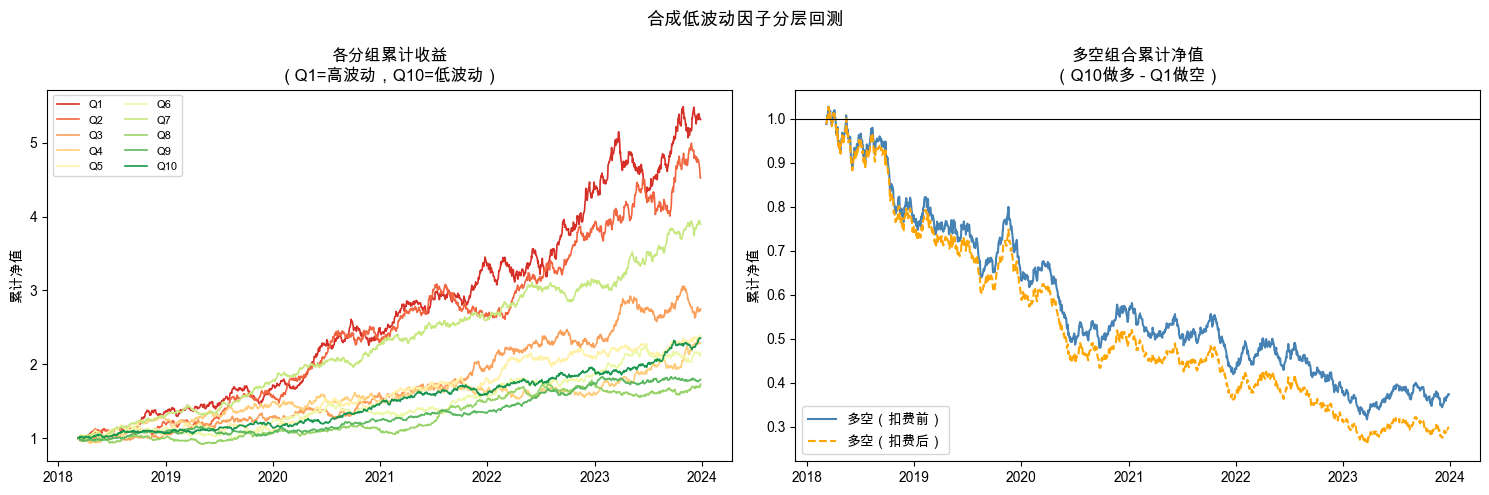

In [9]:
# 分组累计收益图
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：各分组累计收益
ax = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, N_GROUPS))
for i, col in enumerate(group_ret.columns):
    cum = (1 + group_ret[col].dropna()).cumprod()
    ax.plot(cum.index, cum.values, lw=1.2, color=colors[i], label=col)
ax.set_title(f'各分组累计收益\n（Q1=高波动，Q{N_GROUPS}=低波动）')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_ylabel('累计净值')

# 右图：多空组合累计收益
ax = axes[1]
ls_cum = (1 + ls_ret.dropna()).cumprod()
ls_cum_ac = (1 + ls_ret_after_cost.dropna()).cumprod()
ax.plot(ls_cum.index, ls_cum.values, lw=1.5, color='steelblue', label='多空（扣费前）')
ax.plot(ls_cum_ac.index, ls_cum_ac.values, lw=1.5, color='orange', linestyle='--',
        label='多空（扣费后）')
ax.axhline(1, color='black', lw=0.8)
ax.set_title(f'多空组合累计净值\n（Q{N_GROUPS}做多 - Q1做空）')
ax.legend()
ax.set_ylabel('累计净值')

plt.suptitle('合成低波动因子分层回测', fontsize=13)
plt.tight_layout()
plt.show()

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


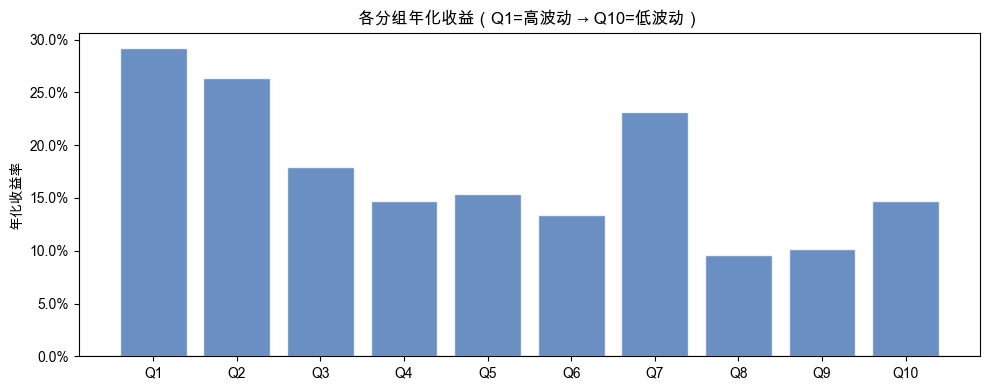

In [10]:
# 分组年化收益柱状图
fig, ax = plt.subplots(figsize=(10, 4))

ann_rets = {col: group_ret[col].dropna().mean() * 252 for col in group_ret.columns}
colors_bar = ['#d73027' if v < 0 else '#4575b4' for v in ann_rets.values()]

ax.bar(list(ann_rets.keys()), list(ann_rets.values()),
       color=colors_bar, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'各分组年化收益（Q1=高波动 → Q{N_GROUPS}=低波动）')
ax.set_ylabel('年化收益率')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

## Section 5: A股低波动异象分析

**核心问题**：A股市场究竟是"高波动溢价"还是"低波动溢价"？

In [11]:
# 计算各分组的波动率
# （用于分析：高波动组 vs 低波动组的实际波动率差异）

group_vol = {}
for col in group_ret.columns:
    g_ret = group_ret[col].dropna()
    group_vol[col] = g_ret.std() * np.sqrt(252)

print('各分组年化波动率:')
for col, v in group_vol.items():
    print(f'  {col}: {v:.2%}')

# 夏普比率比较（风险调整后收益）
print('\n各分组夏普比率（假设无风险利率 3%/年）:')
rf_daily = 0.03 / 252
for col in group_ret.columns:
    g_ret = group_ret[col].dropna()
    excess_ret = g_ret - rf_daily
    sharpe = excess_ret.mean() * 252 / (g_ret.std() * np.sqrt(252))
    print(f'  {col}: {sharpe:.3f}')

各分组年化波动率:
  Q1: 16.71%
  Q2: 15.66%
  Q3: 14.75%
  Q4: 13.90%
  Q5: 12.79%
  Q6: 11.78%
  Q7: 10.20%
  Q8: 9.71%
  Q9: 8.75%
  Q10: 9.26%

各分组夏普比率（假设无风险利率 3%/年）:
  Q1: 1.567
  Q2: 1.490
  Q3: 1.012
  Q4: 0.845
  Q5: 0.966
  Q6: 0.880
  Q7: 1.976
  Q8: 0.680
  Q9: 0.814
  Q10: 1.261


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


...

findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


findfont: Font family 'SimHei' not found.


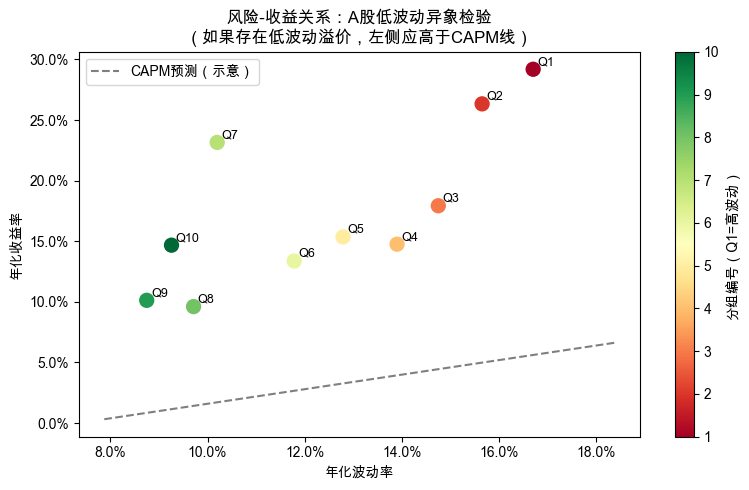

In [12]:
# 年化收益 vs 波动率散点图（验证低波动异象）
fig, ax = plt.subplots(figsize=(8, 5))

ann_rets_list = [group_ret[col].dropna().mean() * 252 for col in group_ret.columns]
ann_vols_list = [group_vol[col] for col in group_ret.columns]
group_nums = list(range(1, N_GROUPS + 1))

scatter = ax.scatter(ann_vols_list, ann_rets_list,
                     c=group_nums, cmap='RdYlGn', s=100, zorder=3)
for i, (v, r, n) in enumerate(zip(ann_vols_list, ann_rets_list, group_nums)):
    ax.annotate(f'Q{n}', (v, r), xytext=(3, 3), textcoords='offset points', fontsize=9)

# CAPM 预测线（理论上收益应随波动率线性增加）
vol_range = np.linspace(min(ann_vols_list) * 0.9, max(ann_vols_list) * 1.1, 100)
capm_line = 0.03 + 0.6 * (vol_range - np.mean(ann_vols_list))  # 简化示意
ax.plot(vol_range, capm_line, 'k--', alpha=0.5, label='CAPM预测（示意）')

ax.set_xlabel('年化波动率')
ax.set_ylabel('年化收益率')
ax.set_title('风险-收益关系：A股低波动异象检验\n（如果存在低波动溢价，左侧应高于CAPM线）')
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend()
plt.colorbar(scatter, ax=ax, label='分组编号（Q1=高波动）')

plt.tight_layout()
plt.show()

In [13]:
# 不同市场环境下的低波动因子表现
# 将样本期分为牛市/熊市/震荡市，检验低波动因子的稳定性

# 基于市场收益率判断市场状态（简化）
market_state = pd.cut(
    market_ret.rolling(60).mean() * 252,  # 60日滚动年化收益率
    bins=[-np.inf, -0.05, 0.05, np.inf],
    labels=['熊市', '震荡市', '牛市']
)

print('各市场状态下多空组合年化收益:')
for state in ['牛市', '震荡市', '熊市']:
    mask = market_state == state
    mask_aligned = mask.reindex(ls_ret.index).fillna(False)
    state_ret = ls_ret[mask_aligned].dropna()
    if len(state_ret) > 20:
        ann = state_ret.mean() * 252
        vol = state_ret.std() * np.sqrt(252)
        sr = ann / vol if vol > 0 else np.nan
        print(f'  {state}: 年化={ann:.2%}, 夏普={sr:.3f}, 样本={len(state_ret)}日')
    else:
        print(f'  {state}: 样本不足（{len(state_ret)}日）')

各市场状态下多空组合年化收益:
  牛市: 年化=-27.42%, 夏普=-1.475, 样本=665日
  震荡市: 年化=9.89%, 夏普=0.465, 样本=140日
  熊市: 年化=-7.41%, 夏普=-0.385, 样本=699日


## Section 6: 结论

### 研究发现

（基于 mock 数据，以下为占位文本，需用真实数据填充）

#### 6.1 因子有效性

| 指标 | 波动率因子 | Beta因子 | 合成因子 |
|------|-----------|----------|--------|
| IC 均值（Rank IC）| - | - | - |
| ICIR | - | - | - |
| t 统计量 | - | - | - |

#### 6.2 低波动异象在A股

**待验证假设**：A股存在低波动溢价（IC均值 > 0，多空组合正收益）

**可能的解释**：
1. **行为偏差**：A股散户比例高，偏好彩票型高波动股票，导致高波动被高估
2. **T+1制度**：日内无法做空，放大了高波动股票的过度定价
3. **涨跌停限制**：连续涨跌停期间的流动性溢价混淆了波动率信号

#### 6.3 因子局限性

1. **市值暴露**：低波动因子往往与大市值正相关，需要市值中性化
2. **行业集中**：低波动股票可能集中于特定行业（如银行、公用事业），需要行业中性化
3. **换仓频率**：Beta因子更新慢（60日窗口），换仓成本相对较低

#### 6.4 后续优化方向

1. 加入行业 + 市值中性化后重新检验
2. 对比不同Beta窗口（20/60/120日）
3. 结合动量因子构建多因子模型（低波动 × 动量）
4. 检验因子在不同市场状态下的稳定性

In [14]:
# 汇总表
from utils.factor_analysis import factor_summary_table

summary = factor_summary_table(
    factors={
        '波动率因子': vol_factor,
        'Beta因子': beta_factor,
        '合成低波动': composite_factor,
    },
    ret_wide=ret_shifted,
    ic_method=IC_METHOD,
)

print('=== 低波动因子汇总 ===')
print(summary.to_string(index=False))

=== 低波动因子汇总 ===
    因子  IC均值(spearman)    ICIR IC>0占比   多空年化  多空夏普
 波动率因子          0.0012  0.0116  49.9% 10.09% 0.784
Beta因子         -0.0043 -0.0393  47.4% 10.07% 0.710
 合成低波动         -0.0028 -0.0269  48.1% 15.36% 1.165
